# 02_data_audit.ipynb

1. Dataset structure
2. Dimensions
3. Coordinates
4. Variables
5. Attributes
6. Spatial coverage
7. Temporal coverage
8. Resolution
9. Units
10. Missing values
11. Valid ranges
12. Basic statistics
13. Simple spatial plots
14. Compare datasets

## 1.SST Dataset

In [1]:
from pathlib import Path

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import dask

In [2]:
import xarray as xr

# ============================================================
# LOAD 5-YEAR RAW DATASETS WITH DASK
# ============================================================

ds_sst = xr.open_dataset(
    "../data/raw/sst/sst_bob_(2).nc",
    chunks={"time": 7}
)

ds_ssh = xr.open_dataset(
    "../data/raw/ssh/ssh_bob_(2).nc",
    chunks={"time": 7}
)

ds_glorys = xr.open_dataset(
    "../data/raw/glorys/glorys_bob_(2).nc",
    chunks={
        "time": 7,
        "depth": -1,
        "latitude": 60,
        "longitude": 80,
    }
)

ds_winds = xr.open_dataset(
    "../data/raw/winds/winds_bob_(2).nc",
    chunks={"time": 7}
)

ds_currents = xr.open_dataset(
    "../data/raw/currents/currents_bob_(2).nc",
    chunks={"time": 7}
)

ds_sss_asc = xr.open_dataset(
    "../data/raw/sss/sss_bob_ascending_(2).nc",
    chunks={"time": 7}
)

ds_sss_desc = xr.open_dataset(
    "../data/raw/sss/sss_bob_descending_(2).nc",
    chunks={"time": 7}
)


print("========== DATASETS LOADED ==========")

datasets = {
    "SST": ds_sst,
    "SSH": ds_ssh,
    "GLORYS": ds_glorys,
    "Winds": ds_winds,
    "Currents": ds_currents,
    "SSS Ascending": ds_sss_asc,
    "SSS Descending": ds_sss_desc,
}

for name, ds in datasets.items():
    print(f"{name:18s} | time={ds.sizes.get('time', 'N/A')}")

print("\n========== CHUNK CHECK ==========")

print("SST:")
print(ds_sst["sea_surface_temperature"].chunks)

print("\nSSH:")
print(ds_ssh["sla"].chunks)

print("\nGLORYS:")
print(ds_glorys["thetao"].chunks)

print("\nWinds:")
print(ds_winds["eastward_wind"].chunks)

print("\nCurrents:")
print(ds_currents["uo"].chunks)

print("\nSSS Ascending:")
print(ds_sss_asc["Sea_Surface_Salinity"].chunks)

print("\nSSS Descending:")
print(ds_sss_desc["Sea_Surface_Salinity"].chunks)

========== DATASETS LOADED ==========
SST                | time=2192
SSH                | time=2192
GLORYS             | time=2192
Winds              | time=2192
Currents           | time=2192
SSS Ascending      | time=2192
SSS Descending     | time=2192

========== CHUNK CHECK ==========
SST:
((7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7

/var/folders/td/2drhj13564q4g1_p8t7srtk80000gn/T/ipykernel_46466/2803319410.py:7: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 7. This could degrade performance. Instead, consider rechunking after loading.
  ds_sst = xr.open_dataset(
/var/folders/td/2drhj13564q4g1_p8t7srtk80000gn/T/ipykernel_46466/2803319410.py:12: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 7. This could degrade performance. Instead, consider rechunking after loading.
  ds_ssh = xr.open_dataset(
/var/folders/td/2drhj13564q4g1_p8t7srtk80000gn/T/ipykernel_46466/2803319410.py:17: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 7. This could degrade performance. Instead, consider rechunking after loading.
  ds_glorys = xr.open_dataset(
/var/folders/td/2drhj13564q4g1_p8t7srtk80000gn/T/ipykernel_46466/2803319410.py:17: UserWarning: The specified chunks separ

In [3]:
def spatial_coverage(ds, name):
    lat = ds["latitude"]
    lon = ds["longitude"]

    print(f"\n{name}")
    print("-" * 40)
    print(f"Latitude:  {lat.min().compute().item():.4f} to {lat.max().compute().item():.4f}")
    print(f"Longitude: {lon.min().compute().item():.4f} to {lon.max().compute().item():.4f}")


print("Spatial Coverage of Datasets")
print("=" * 40)

spatial_coverage(ds_sst, "SST")
spatial_coverage(ds_ssh, "SSH")
spatial_coverage(ds_glorys, "GLORYS")
spatial_coverage(ds_winds, "Winds")
spatial_coverage(ds_currents, "Currents")
spatial_coverage(ds_sss_asc, "SSS Ascending")
spatial_coverage(ds_sss_desc, "SSS Descending")

Spatial Coverage of Datasets

SST
----------------------------------------
Latitude:  5.0500 to 19.9500
Longitude: 80.0500 to 99.9500

SSH
----------------------------------------
Latitude:  5.1250 to 19.8750
Longitude: 80.1250 to 99.8750

GLORYS
----------------------------------------
Latitude:  5.0000 to 20.0000
Longitude: 80.0000 to 100.0000

Winds
----------------------------------------
Latitude:  5.1250 to 19.8750
Longitude: 80.1250 to 99.8750

Currents
----------------------------------------
Latitude:  5.1250 to 19.8750
Longitude: 80.1250 to 99.8750

SSS Ascending
----------------------------------------
Latitude:  5.0000 to 19.8000
Longitude: 80.2000 to 100.0000

SSS Descending
----------------------------------------
Latitude:  5.0000 to 19.8000
Longitude: 80.2000 to 100.0000


In [4]:
def temporal_coverage(ds, name):
    time = ds["time"]

    print(f"\n{name}")
    print("-" * 40)
    print(f"Time: {time.min().compute().item()} to {time.max().compute().item()}")
    print(f"Count: {time.size}")


print("\nTemporal Coverage of Datasets")
print("=" * 40)

temporal_coverage(ds_sst, "SST")
temporal_coverage(ds_ssh, "SSH")
temporal_coverage(ds_glorys, "GLORYS")
temporal_coverage(ds_winds, "Winds")
temporal_coverage(ds_currents, "Currents")
temporal_coverage(ds_sss_asc, "SSS Ascending")
temporal_coverage(ds_sss_desc, "SSS Descending")


Temporal Coverage of Datasets

SST
----------------------------------------
Time: 1577836800000000000 to 1767139200000000000
Count: 2192

SSH
----------------------------------------
Time: 1577836800000000000 to 1767139200000000000
Count: 2192

GLORYS
----------------------------------------
Time: 1577836800000000000 to 1767139200000000000
Count: 2192

Winds
----------------------------------------
Time: 1577836800000000000 to 1767139200000000000
Count: 2192

Currents
----------------------------------------
Time: 1577836800000000000 to 1767139200000000000
Count: 2192

SSS Ascending
----------------------------------------
Time: 1577836800000000000 to 1767139200000000000
Count: 2192

SSS Descending
----------------------------------------
Time: 1577836800000000000 to 1767139200000000000
Count: 2192


In [5]:
def dataset_review(ds, name):
    print(f"\n{name}")
    print(ds.dims)
    print(ds.coords)
    print(ds.data_vars)
    print(ds.attrs)

In [6]:
print("\nDataset Review")
print("=" * 40)
print(dataset_review(ds_sst, "SST"))
print(dataset_review(ds_ssh, "SSH"))
print(dataset_review(ds_glorys, "GLORYS"))
print(dataset_review(ds_winds, "Winds"))
print(dataset_review(ds_currents, "Currents"))
print(dataset_review(ds_sss_asc, "SSS Ascending"))
print(dataset_review(ds_sss_desc, "SSS Descending"))


Dataset Review

SST
FrozenMappingWarningOnValuesAccess({'time': 2192, 'latitude': 150, 'longitude': 200})
Coordinates:
  * time       (time) datetime64[ns] 18kB 2020-01-01 2020-01-02 ... 2025-12-31
  * latitude   (latitude) float64 1kB 5.05 5.15 5.25 5.35 ... 19.75 19.85 19.95
  * longitude  (longitude) float64 2kB 80.05 80.15 80.25 ... 99.75 99.85 99.95
Data variables:
    sea_surface_temperature  (time, latitude, longitude) float64 526MB dask.array<chunksize=(7, 10, 25), meta=np.ndarray>
{'Conventions': 'CF-1.7,ACDD-1.3,ISO 8601', 'acknowledgment': 'Please acknowledge the use of these data with the following statement: these data were obtained from Copernicus Marine Service and produced by the Centre de Recherche et d Exploitation Satellitaire (CERSAT), at Ifremer, Plouzane (France', 'cdm_data_type': 'grid', 'cmems_product_id': 'SST_GLO_PHY_L3S_MY_010_039', 'comment': 'WARNING:Some applications are unable to properly handle signed byte values. If values are encountered > 127, please

In [7]:
def data_array_review(ds, name):
    print(f"\n{name}")
    da=ds[name]
    print(da.dims)
    print(da.coords)
    print(da.attrs)

In [8]:
print("\nDataset Data Array Names")
print("=" * 40) 
print(ds_sst.data_vars)
print(ds_ssh.data_vars)
print(ds_glorys.data_vars)
print(ds_winds.data_vars)
print(ds_currents.data_vars)
print(ds_sss_asc.data_vars)
print(ds_sss_desc.data_vars)


Dataset Data Array Names
Data variables:
    sea_surface_temperature  (time, latitude, longitude) float64 526MB dask.array<chunksize=(7, 10, 25), meta=np.ndarray>
Data variables:
    sla      (time, latitude, longitude) float64 84MB dask.array<chunksize=(7, 8, 10), meta=np.ndarray>
Data variables:
    thetao   (time, depth, latitude, longitude) float64 28GB dask.array<chunksize=(7, 36, 60, 80), meta=np.ndarray>
Data variables:
    eastward_wind   (time, latitude, longitude) float64 84MB dask.array<chunksize=(7, 8, 10), meta=np.ndarray>
    northward_wind  (time, latitude, longitude) float64 84MB dask.array<chunksize=(7, 8, 10), meta=np.ndarray>
Data variables:
    uo       (time, depth, latitude, longitude) float64 84MB dask.array<chunksize=(7, 1, 8, 10), meta=np.ndarray>
    vo       (time, depth, latitude, longitude) float64 84MB dask.array<chunksize=(7, 1, 8, 10), meta=np.ndarray>
Data variables:
    Sea_Surface_Salinity  (time, latitude, longitude) float32 66MB dask.array<chunksiz

In [9]:
print("\nData Array Review")
print("=" * 40)
print(data_array_review(ds_sst, "sea_surface_temperature"))
print(data_array_review(ds_ssh, "sla"))  
print(data_array_review(ds_glorys, "thetao"))
print(data_array_review(ds_winds, "eastward_wind"))
print(data_array_review(ds_winds, "northward_wind"))
print(data_array_review(ds_currents, "uo"))
print(data_array_review(ds_currents, "vo"))
print(data_array_review(ds_sss_asc, "Sea_Surface_Salinity"))
print(data_array_review(ds_sss_desc, "Sea_Surface_Salinity"))


Data Array Review

sea_surface_temperature
('time', 'latitude', 'longitude')
Coordinates:
  * time       (time) datetime64[ns] 18kB 2020-01-01 2020-01-02 ... 2025-12-31
  * latitude   (latitude) float64 1kB 5.05 5.15 5.25 5.35 ... 19.75 19.85 19.95
  * longitude  (longitude) float64 2kB 80.05 80.15 80.25 ... 99.75 99.85 99.95
{'authority': 'CF-1.7', 'long_name': 'sea surface temperature', 'standard_name': 'sea_surface_foundation_temperature', 'type': 'foundation', 'units': 'kelvin', 'valid_max': np.int16(4500), 'valid_min': np.int16(-300)}
None

sla
('time', 'latitude', 'longitude')
Coordinates:
  * time       (time) datetime64[ns] 18kB 2020-01-01 2020-01-02 ... 2025-12-31
  * latitude   (latitude) float32 240B 5.125 5.375 5.625 ... 19.38 19.62 19.88
  * longitude  (longitude) float32 320B 80.12 80.38 80.62 ... 99.38 99.62 99.88
{'ancillary_variables': 'err_sla', 'comment': 'The sea level anomaly is the sea surface height above mean sea surface; it is referenced to the [1993, 2012] pe

In [10]:
def data_array_statistics(ds, name):

    print(f"\n{name}")
    print("-" * 40)

    da = ds[name]

    print("Units:", da.attrs.get("units", "unknown"))
    print("Shape:", da.shape)
    print("Chunks:", da.chunks)

    missing_pct = (
        100 * da.isnull().mean()
    ).compute().item()

    print(f"Missing: {missing_pct:.2f}%")


print("\nData Array Statistics")
print("=" * 40)

data_array_statistics(ds_sst, "sea_surface_temperature")
data_array_statistics(ds_ssh, "sla")
data_array_statistics(ds_glorys, "thetao")
data_array_statistics(ds_winds, "eastward_wind")
data_array_statistics(ds_winds, "northward_wind")
data_array_statistics(ds_currents, "uo")
data_array_statistics(ds_currents, "vo")
data_array_statistics(ds_sss_asc, "Sea_Surface_Salinity")
data_array_statistics(ds_sss_desc, "Sea_Surface_Salinity")


Data Array Statistics

sea_surface_temperature
----------------------------------------
Units: kelvin
Shape: (2192, 150, 200)
Chunks: ((7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7,

In [11]:
def missing_value_audit(ds, name):

    print(f"\n{name}")
    print("-" * 50)

    for var_name, var in ds.data_vars.items():

        missing_percent = (
            100 * var.isnull().mean()
        ).compute().item()

        print(f"{var_name}")
        print(f"  Total values:   {var.size:,}")
        print(f"  Missing %:      {missing_percent:.4f}%")

In [12]:
print("\nMissing Value Audit")
print("=" * 50)

missing_value_audit(ds_sst, "SST")
missing_value_audit(ds_ssh, "SSH")
missing_value_audit(ds_glorys, "GLORYS")
missing_value_audit(ds_winds, "Winds")
missing_value_audit(ds_currents, "Currents")
missing_value_audit(ds_sss_asc, "SSS Ascending")
missing_value_audit(ds_sss_desc, "SSS Descending")


Missing Value Audit

SST
--------------------------------------------------
sea_surface_temperature
  Total values:   65,760,000
  Missing %:      73.1044%

SSH
--------------------------------------------------
sla
  Total values:   10,521,600
  Missing %:      15.8958%

GLORYS
--------------------------------------------------
thetao
  Total values:   3,442,220,352
  Missing %:      26.4460%

Winds
--------------------------------------------------
eastward_wind
  Total values:   10,521,600
  Missing %:      72.3469%
northward_wind
  Total values:   10,521,600
  Missing %:      72.3469%

Currents
--------------------------------------------------
uo
  Total values:   10,521,600
  Missing %:      18.8349%
vo
  Total values:   10,521,600
  Missing %:      18.8350%

SSS Ascending
--------------------------------------------------
Sea_Surface_Salinity
  Total values:   16,440,000
  Missing %:      91.1275%

SSS Descending
--------------------------------------------------
Sea_Surface_Sa

In [13]:
def spatial_resolution(ds, name):

    lat = ds["latitude"]
    lon = ds["longitude"]

    lat_diff = lat.diff("latitude")
    lon_diff = lon.diff("longitude")

    print(f"\n{name}")
    print("-" * 40)

    print(
        f"Latitude spacing:  "
        f"{lat_diff.min().compute().item():.6f} "
        f"to {lat_diff.max().compute().item():.6f}"
    )

    print(
        f"Longitude spacing: "
        f"{lon_diff.min().compute().item():.6f} "
        f"to {lon_diff.max().compute().item():.6f}"
    )

In [14]:
print("\nSpatial Resolution of Datasets")
print("=" * 40)
print(spatial_resolution(ds_sst, "SST"))
print(spatial_resolution(ds_ssh, "SSH"))
print(spatial_resolution(ds_glorys, "GLORYS"))
print(spatial_resolution(ds_winds, "Winds"))
print(spatial_resolution(ds_currents, "Currents"))
print(spatial_resolution(ds_sss_asc, "SSS Ascending"))
print(spatial_resolution(ds_sss_desc, "SSS Descending"))


Spatial Resolution of Datasets

SST
----------------------------------------
Latitude spacing:  0.099998 to 0.100000
Longitude spacing: 0.099998 to 0.100006
None

SSH
----------------------------------------
Latitude spacing:  0.250000 to 0.250000
Longitude spacing: 0.250000 to 0.250000
None

GLORYS
----------------------------------------
Latitude spacing:  0.083332 to 0.083334
Longitude spacing: 0.083328 to 0.083336
None

Winds
----------------------------------------
Latitude spacing:  0.250000 to 0.250000
Longitude spacing: 0.250000 to 0.250000
None

Currents
----------------------------------------
Latitude spacing:  0.250000 to 0.250000
Longitude spacing: 0.250000 to 0.250000
None

SSS Ascending
----------------------------------------
Latitude spacing:  0.200000 to 0.200000
Longitude spacing: 0.200000 to 0.200000
None

SSS Descending
----------------------------------------
Latitude spacing:  0.200000 to 0.200000
Longitude spacing: 0.200000 to 0.200000
None


In [15]:
import matplotlib.pyplot as plt

In [39]:
def plot_spatial(da, name, time_index=0, depth_index=None):
    if "time" in da.dims:
        da = da.isel(time=time_index)

    if depth_index is not None and "depth" in da.dims:
        da = da.isel(depth=depth_index)

    plt.figure(figsize=(8, 5))
    da.plot()
    plt.title(name)
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.tight_layout()

    # Save the plot
    filename = f"../outputs/figures/{name.replace(' ', '_')}.png"
    plt.savefig(filename)
    plt.show()

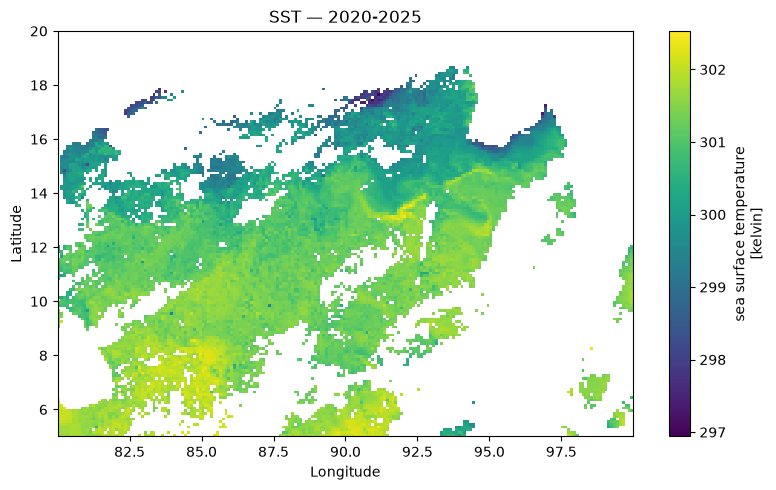

In [40]:
plot_spatial(
    ds_sst["sea_surface_temperature"],
    "SST — 2020-2025"
)

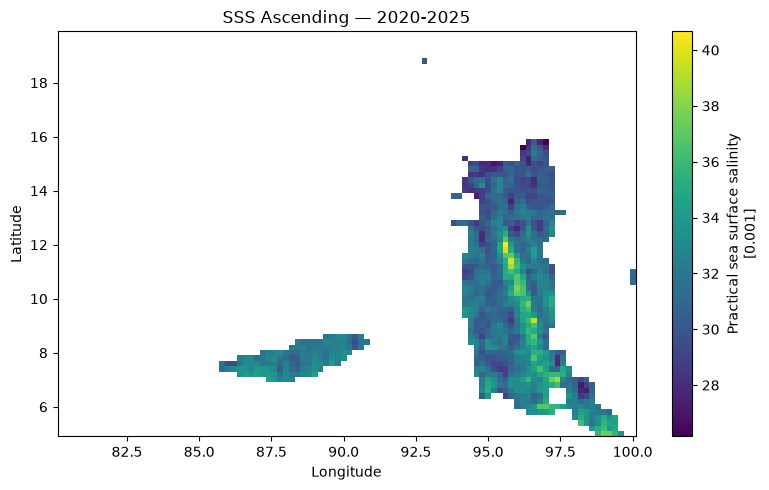

In [41]:
plot_spatial(
    ds_sss_asc["Sea_Surface_Salinity"],
    "SSS Ascending — 2020-2025"
)

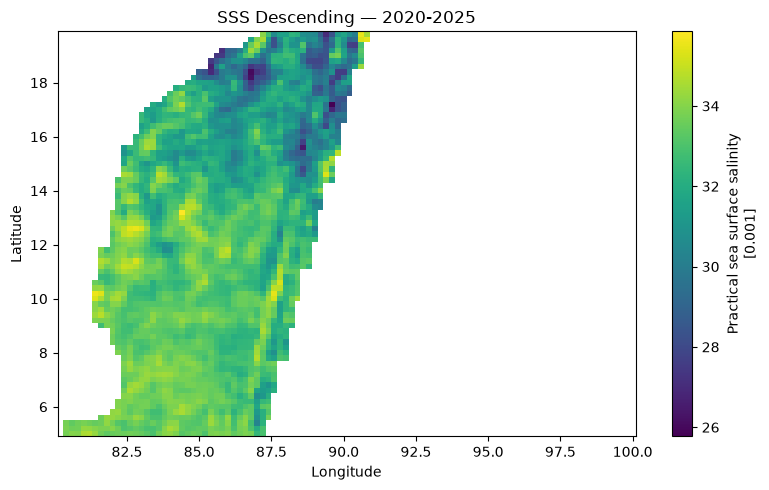

In [42]:
plot_spatial(
    ds_sss_desc["Sea_Surface_Salinity"],
    "SSS Descending — 2020-2025"
)

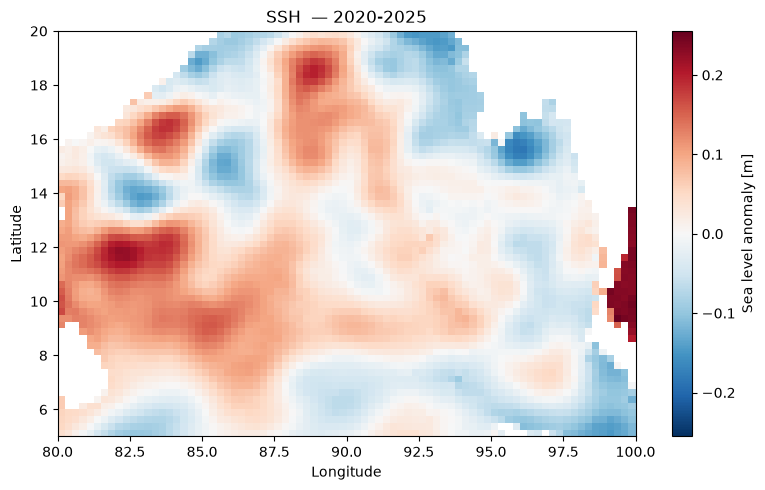

In [44]:
plot_spatial(
    ds_ssh["sla"],
    "SSH  — 2020-2025"
)

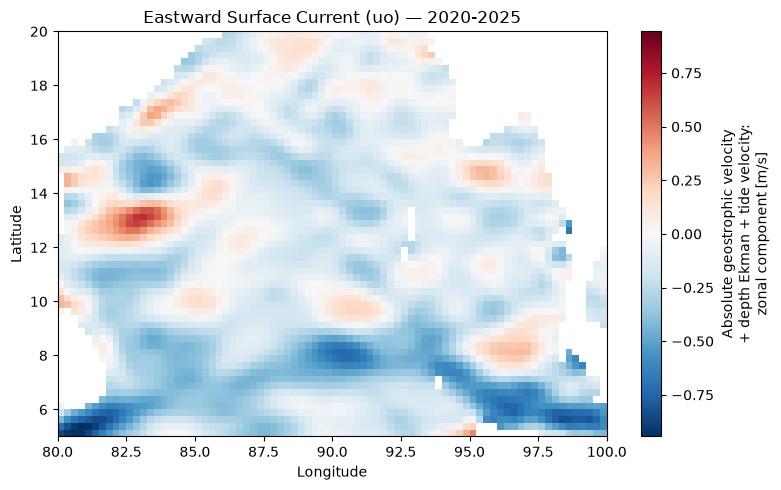

In [45]:
plot_spatial(
    ds_currents["uo"],
    "Eastward Surface Current (uo) — 2020-2025"
)

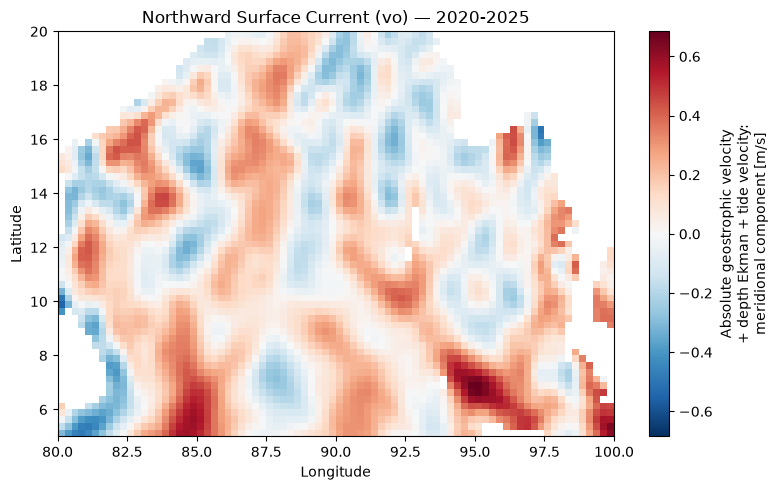

In [46]:
plot_spatial(
    ds_currents["vo"],
    "Northward Surface Current (vo) — 2020-2025"
)

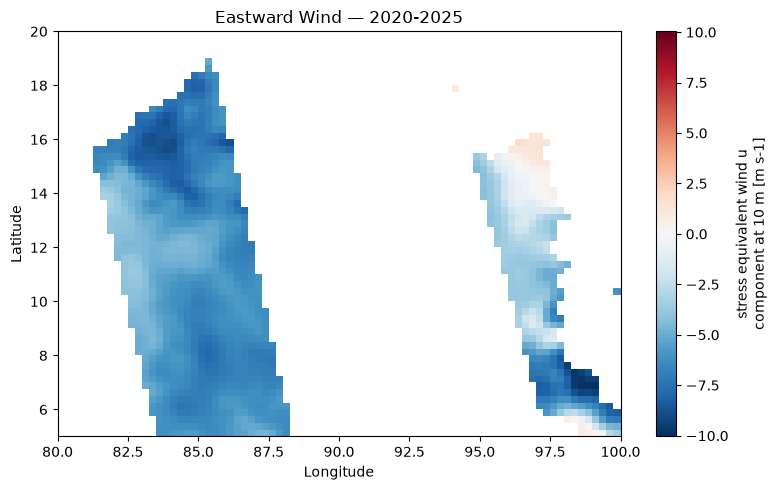

In [47]:
plot_spatial(
    ds_winds["eastward_wind"],
    "Eastward Wind — 2020-2025"
)

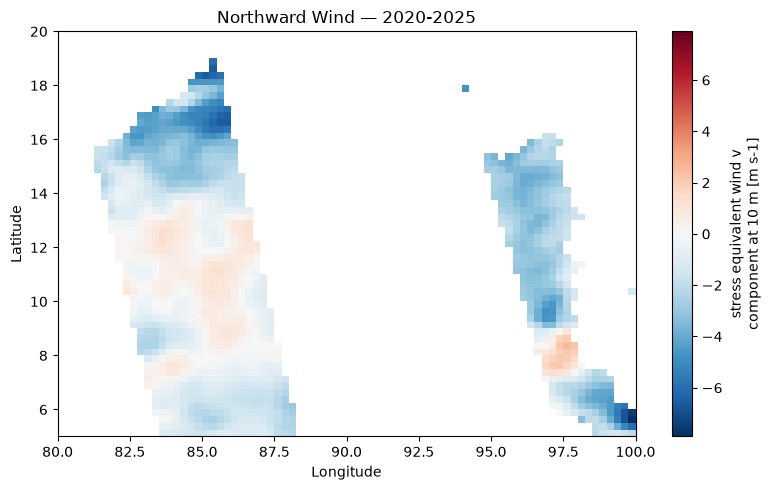

In [48]:
plot_spatial(
    ds_winds["northward_wind"],
    "Northward Wind — 2020-2025"
)

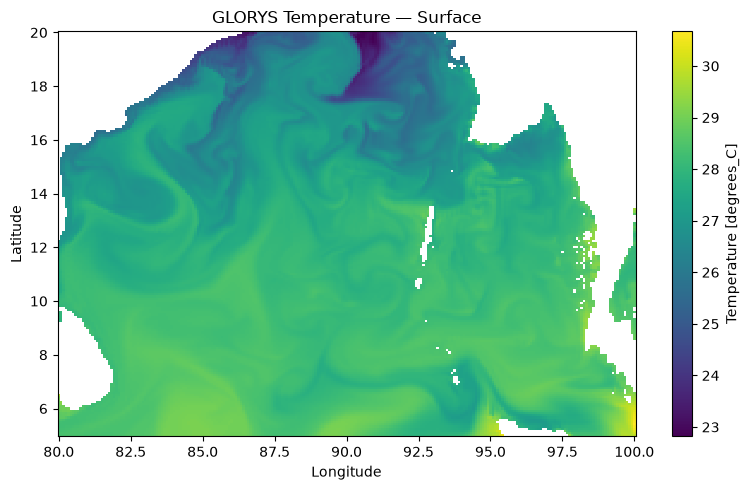

In [49]:
plot_spatial(
    ds_glorys["thetao"],
    "GLORYS Temperature — Surface",
    depth_index=0
)

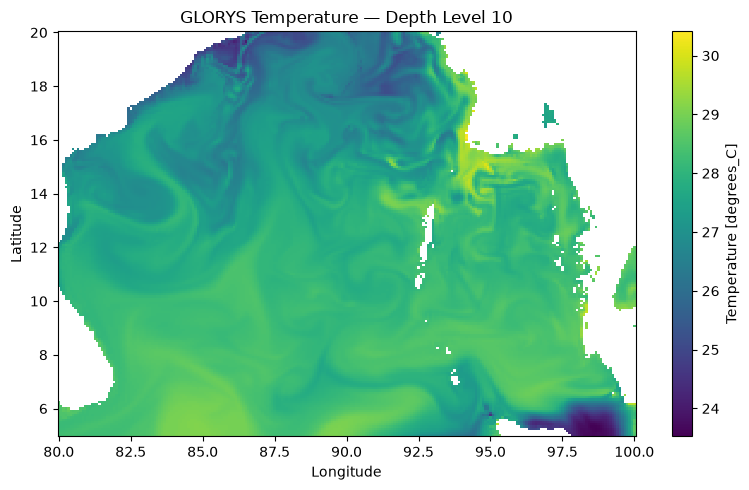

In [50]:
plot_spatial(
    ds_glorys["thetao"],
    "GLORYS Temperature — Depth Level 10",
    depth_index=10
)

In [28]:
def compare_grid(ds, name):

    lat = ds["latitude"]
    lon = ds["longitude"]

    lat_spacing = lat.diff("latitude")
    lon_spacing = lon.diff("longitude")

    print(f"\n{name}")
    print("-" * 60)

    print(
        f"Latitude:  "
        f"{lat.min().compute().item():.4f} → "
        f"{lat.max().compute().item():.4f}"
    )

    print(
        f"Longitude: "
        f"{lon.min().compute().item():.4f} → "
        f"{lon.max().compute().item():.4f}"
    )

    print(f"Shape:     {lat.size} × {lon.size}")

    print(
        f"Lat step:  "
        f"{lat_spacing.mean().compute().item():.6f}°"
    )

    print(
        f"Lon step:  "
        f"{lon_spacing.mean().compute().item():.6f}°"
    )

In [29]:
for name, ds in datasets.items():

    lat = ds["latitude"]
    lon = ds["longitude"]

    print(
        f"{name:12s} | "
        f"lat {lat.min().compute().item():.3f} → "
        f"{lat.max().compute().item():.3f} | "
        f"lon {lon.min().compute().item():.3f} → "
        f"{lon.max().compute().item():.3f}"
    )

SST          | lat 5.050 → 19.950 | lon 80.050 → 99.950
SSH          | lat 5.125 → 19.875 | lon 80.125 → 99.875
GLORYS       | lat 5.000 → 20.000 | lon 80.000 → 100.000
Winds        | lat 5.125 → 19.875 | lon 80.125 → 99.875
Currents     | lat 5.125 → 19.875 | lon 80.125 → 99.875
SSS Ascending | lat 5.000 → 19.800 | lon 80.200 → 100.000
SSS Descending | lat 5.000 → 19.800 | lon 80.200 → 100.000


In [30]:
def compare_time(ds, name):
    time = ds["time"]

    print(
        f"{name:20s} | "
        f"start={time.min().values} | "
        f"end={time.max().values} | "
        f"count={time.size}"
    )

In [31]:
compare_time(ds_sst, "SST")
compare_time(ds_sss_asc, "SSS Asc")
compare_time(ds_sss_desc, "SSS Desc")
compare_time(ds_ssh, "SSH")
compare_time(ds_currents, "Currents")
compare_time(ds_winds, "Winds")
compare_time(ds_glorys, "GLORYS")

SST                  | start=2020-01-01T00:00:00.000000000 | end=2025-12-31T00:00:00.000000000 | count=2192
SSS Asc              | start=2020-01-01T00:00:00.000000000 | end=2025-12-31T00:00:00.000000000 | count=2192
SSS Desc             | start=2020-01-01T00:00:00.000000000 | end=2025-12-31T00:00:00.000000000 | count=2192
SSH                  | start=2020-01-01T00:00:00.000000000 | end=2025-12-31T00:00:00.000000000 | count=2192
Currents             | start=2020-01-01T00:00:00.000000000 | end=2025-12-31T00:00:00.000000000 | count=2192
Winds                | start=2020-01-01T00:00:00.000000000 | end=2025-12-31T00:00:00.000000000 | count=2192
GLORYS               | start=2020-01-01T00:00:00.000000000 | end=2025-12-31T00:00:00.000000000 | count=2192


In [32]:
datasets = {
    "SST": ds_sst,
    "SSS Asc": ds_sss_asc,
    "SSS Desc": ds_sss_desc,
    "SSH": ds_ssh,
    "Currents": ds_currents,
    "Winds": ds_winds,
    "GLORYS": ds_glorys,
}

In [33]:
for name, ds in datasets.items():
    lat = ds["latitude"]
    lon = ds["longitude"]

    print(
        f"{name:12s} | "
        f"lat {lat.min().item():.3f} → {lat.max().item():.3f} | "
        f"lon {lon.min().item():.3f} → {lon.max().item():.3f}"
    )

SST          | lat 5.050 → 19.950 | lon 80.050 → 99.950
SSS Asc      | lat 5.000 → 19.800 | lon 80.200 → 100.000
SSS Desc     | lat 5.000 → 19.800 | lon 80.200 → 100.000
SSH          | lat 5.125 → 19.875 | lon 80.125 → 99.875
Currents     | lat 5.125 → 19.875 | lon 80.125 → 99.875
Winds        | lat 5.125 → 19.875 | lon 80.125 → 99.875
GLORYS       | lat 5.000 → 20.000 | lon 80.000 → 100.000


### SSS ascending VS descending

In [34]:
sss_asc = ds_sss_asc["Sea_Surface_Salinity"]
sss_desc = ds_sss_desc["Sea_Surface_Salinity"]

In [35]:
print(sss_asc.dims)
print(sss_desc.dims)

print(sss_asc.latitude.equals(sss_desc.latitude))
print(sss_asc.longitude.equals(sss_desc.longitude))  #we observe the coordinates are identical
print(sss_asc.time.equals(sss_desc.time))

('time', 'latitude', 'longitude')
('time', 'latitude', 'longitude')
True
True
True


In [36]:
sss_difference = sss_asc - sss_desc

print("SSS difference")
print("-" * 40)

difference_stats = {
    "min": sss_difference.min(),
    "max": sss_difference.max(),
    "mean": sss_difference.mean(),
}

difference_stats = {
    name: value.compute().item()
    for name, value in difference_stats.items()
}

print("Min: ", difference_stats["min"])
print("Max: ", difference_stats["max"])
print("Mean:", difference_stats["mean"])

SSS difference
----------------------------------------
Min:  -33.20182800292969
Max:  22.009437561035156
Mean: 0.14728672802448273


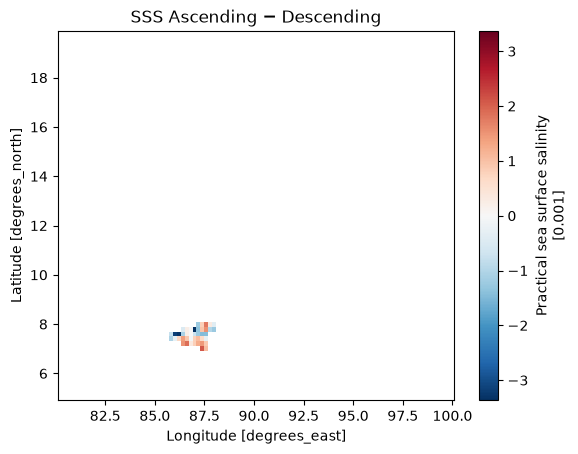

In [37]:
sss_difference.isel(time=0).plot()
plt.title("SSS Ascending − Descending")
plt.show()

In [38]:
print("SST vs SSH latitude:",
      ds_sst.latitude.equals(ds_ssh.latitude)) #it shows false,this is what we need to solve in preprocessing

print("SST vs SSH longitude:",
      ds_sst.longitude.equals(ds_ssh.longitude))

SST vs SSH latitude: False
SST vs SSH longitude: False
